<a href="https://colab.research.google.com/github/Akshatha7710/RAG-based-Document-Question-Answering-System-using-LangChain-FAISS-and-LLMs/blob/main/Question%20Answering%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG-Based Document Question Answering System
**Stack:** PyMuPDF · python-docx · ChromaDB (persistent) · Sentence-Transformers · Gemini 2.5 Flash

In [1]:
# Cell 1: Install Dependencies
!pip install -q pymupdf python-docx chromadb sentence-transformers \\
               langchain-text-splitters google-generativeai tqdm nltk matplotlib

ERROR: Invalid requirement: '': Expected package name at the start of dependency specifier
    
    ^


In [2]:
# Cell 2: Set API Key
import os

try:
    from google.colab import userdata
    api_key = userdata.get("GEMINI_API_KEY")
except ImportError:
    api_key = os.environ.get("GEMINI_API_KEY", "")

if not api_key or len(api_key) < 10:
    raise ValueError(
        "\u274c GEMINI_API_KEY secret is missing or looks invalid.\n"
        "Add it via Colab Secrets (\U0001f511 icon in the left sidebar) "
        "or set the environment variable before running."
    )

os.environ["GEMINI_API_KEY"] = api_key
print("\u2705 API Key loaded:", api_key[:10], "...")

✅ API Key loaded: AIzaSyDFX_ ...


In [4]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "pymupdf"],
    capture_output=True, text=True
)

try:
    import fitz
    print(f"✅ pymupdf OK (fitz {fitz.__version__})")
except ImportError as e:
    print("❌ Still failed:", e)

✅ pymupdf OK (fitz 1.27.2.3)


In [7]:
!pip install python-docx
import docx
print("✅ docx OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.6 MB/s eta 0:00:00
✅ docx OK


In [9]:
!pip install pymupdf python-docx chromadb sentence-transformers langchain-text-splitters google-generativeai tqdm nltk matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentelem

In [10]:
# Cell 3: Imports & Setup
import fitz
import docx
import chromadb
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
import time, os, threading

# ── Central configuration ──────────────────────────────────────────
CONFIG = {
    "model":               "gemini-2.5-flash-preview-05-20",  # pinned stable release
    "embedder":            "all-MiniLM-L6-v2",
    "chunk_size":          500,
    "chunk_overlap":       100,
    "top_k":               5,
    "relevance_threshold": 0.35,
    "db_path":             "/content/chroma_db",
    "max_retries":         5,
    "rpm_limit":           10,
}

# ── Gemini ────────────────────────────────────────────────────────
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
llm = genai.GenerativeModel(CONFIG["model"])

# ── Embedding model ───────────────────────────────────────────────
embedder = SentenceTransformer(CONFIG["embedder"])

# ── Persistent vector database ────────────────────────────────────
# For true persistence across sessions, mount Drive and set db_path:
#   from google.colab import drive; drive.mount('/content/drive')
#   CONFIG['db_path'] = "/content/drive/MyDrive/rag_chroma_db"
chroma     = chromadb.PersistentClient(path=CONFIG["db_path"])
collection = chroma.get_or_create_collection(
    "docs", metadata={"hnsw:space": "cosine"}
)

# ── Text splitter ─────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG["chunk_size"],
    chunk_overlap=CONFIG["chunk_overlap"],
)

# ── Token-bucket rate limiter (avoids hard sleep between calls) ───
class RateLimiter:
    """Allow at most `rpm` calls per 60 seconds."""
    def __init__(self, rpm: int) -> None:
        self.interval = 60.0 / rpm
        self._lock     = threading.Lock()
        self._last     = 0.0

    def wait(self) -> None:
        with self._lock:
            now = time.monotonic()
            gap = self.interval - (now - self._last)
            if gap > 0:
                time.sleep(gap)
            self._last = time.monotonic()

_rate_limiter = RateLimiter(CONFIG["rpm_limit"])

print(f"\u2705 All components initialized")
print(f"\U0001f4c2 Vector DB path: {CONFIG['db_path']}")
print(f"\U0001f4c4 Documents already in collection: {collection.count()}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ All components initialized
📂 Vector DB path: /content/chroma_db
📄 Documents already in collection: 0


In [11]:
# Cell 4: Core Functions

# ── Streaming Gemini call ─────────────────────────────────────────
def call_gemini(
    prompt: str,
    stream: bool = True,
    max_attempts: int = CONFIG["max_retries"],
) -> str:
    """
    Call Gemini with exponential backoff.

    Args:
        prompt: The text prompt to send.
        stream: If True, tokens print live and the full text is returned.
        max_attempts: Number of retry attempts on transient errors.

    Returns:
        The model's response as a string, or an error message.
    """
    for attempt in range(max_attempts):
        try:
            _rate_limiter.wait()
            if stream:
                chunks_out: list[str] = []
                for chunk in llm.generate_content(prompt, stream=True):
                    print(chunk.text, end="", flush=True)
                    chunks_out.append(chunk.text)
                print()
                return "".join(chunks_out)
            else:
                return llm.generate_content(prompt).text
        except Exception as e:
            if attempt == max_attempts - 1:
                return f"\u274c Failed after {max_attempts} attempts: {e}"
            wait_secs = 2 ** attempt * 5
            print(f"\u26a0\ufe0f  Attempt {attempt+1} failed — retrying in {wait_secs}s… ({e})")
            time.sleep(wait_secs)
    return ""  # unreachable, satisfies type checkers


# ── Text extraction (PDF, DOCX, TXT, MD, HTML) ───────────────────
_SUPPORTED_EXTENSIONS = {".pdf", ".docx", ".txt", ".md", ".html", ".htm"}

def extract_text(path: str) -> str:
    """
    Extract plain text from a document.

    Supported formats: .pdf, .docx, .txt, .md, .html/.htm

    Args:
        path: Absolute or relative path to the file.

    Returns:
        Extracted text as a single string.

    Raises:
        ValueError: If the file extension is not supported.
        FileNotFoundError: If the file does not exist.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"File not found: '{path}'")

    ext = os.path.splitext(path)[1].lower()

    if ext == ".pdf":
        with fitz.open(path) as doc:
            return "\n\n".join(page.get_text() for page in doc)

    elif ext == ".docx":
        document = docx.Document(path)
        return "\n\n".join(p.text for p in document.paragraphs if p.text.strip())

    elif ext in (".txt", ".md"):
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            return f.read()

    elif ext in (".html", ".htm"):
        try:
            from bs4 import BeautifulSoup
            with open(path, "r", encoding="utf-8", errors="replace") as f:
                soup = BeautifulSoup(f, "html.parser")
            return soup.get_text(separator="\n", strip=True)
        except ImportError:
            # Fallback: strip tags with a simple regex
            import re
            with open(path, "r", encoding="utf-8", errors="replace") as f:
                raw = f.read()
            return re.sub(r"<[^>]+>", " ", raw)

    else:
        raise ValueError(
            f"Unsupported file type '{ext}'. "
            f"Supported: {', '.join(sorted(_SUPPORTED_EXTENSIONS))}"
        )


# ── Ingestion ─────────────────────────────────────────────────────
def ingest_file(path: str) -> None:
    """Ingest a single document into the vector store."""
    filename = os.path.basename(path)
    try:
        text = extract_text(path)
    except (ValueError, FileNotFoundError) as e:
        print(f"\u26a0\ufe0f  Skipping '{filename}': {e}")
        return

    if not text.strip():
        print(f"\u26a0\ufe0f  '{filename}' appears empty — skipping.")
        return

    chunks     = splitter.split_text(text)
    embeddings = embedder.encode(chunks, show_progress_bar=True).tolist()
    ids        = [f"{filename}_chunk_{i}" for i in range(len(chunks))]
    metadatas  = [{"source": filename, "chunk_index": i} for i in range(len(chunks))]
    collection.upsert(ids=ids, embeddings=embeddings, documents=chunks, metadatas=metadatas)
    print(f"\u2705 Ingested {len(chunks)} chunks from '{filename}'")


def ingest_multiple_files(paths: list[str]) -> None:
    """Ingest a list of documents into the vector store."""
    for path in tqdm(paths, desc="Ingesting files"):
        ingest_file(path)
    print(f"\n\U0001f4da Total chunks in DB: {collection.count()}")


# Backward-compatible aliases
ingest_pdf           = ingest_file
ingest_multiple_pdfs = ingest_multiple_files


# ── Delete / clear utilities ──────────────────────────────────────
def delete_source(filename: str) -> None:
    """Remove all chunks for a specific source file from the vector store."""
    results = collection.get(where={"source": filename}, include=["metadatas"])
    ids_to_delete = results["ids"]
    if not ids_to_delete:
        print(f"\u26a0\ufe0f  No chunks found for '{filename}'. Check with list_sources().")
        return
    collection.delete(ids=ids_to_delete)
    print(f"\U0001f5d1\ufe0f  Deleted {len(ids_to_delete)} chunks from '{filename}'")


def clear_collection(confirm: bool = False) -> None:
    """
    Delete ALL documents from the vector store.

    Args:
        confirm: Must be True to actually delete. Safety guard.

    Example::

        clear_collection(confirm=True)
    """
    if not confirm:
        print("\u26a0\ufe0f  Pass confirm=True to clear the entire collection.")
        return
    all_ids = collection.get()["ids"]
    if not all_ids:
        print("Collection is already empty.")
        return
    collection.delete(ids=all_ids)
    print(f"\U0001f5d1\ufe0f  Cleared {len(all_ids)} chunks from the collection.")


# ── List / require helpers ────────────────────────────────────────
def list_sources() -> None:
    """Print a summary of all ingested documents and their chunk counts."""
    total = collection.count()
    if total == 0:
        print("\u26a0\ufe0f  Vector store is empty. Run Cell 5 first.")
        return
    all_meta = collection.get(include=["metadatas"])["metadatas"]
    sources: dict[str, int] = {}
    for m in all_meta:
        src = m.get("source", "unknown")
        sources[src] = sources.get(src, 0) + 1
    print(f"\U0001f4da {total} total chunks from {len(sources)} file(s):")
    for src, count in sorted(sources.items()):
        print(f"   \u2022 {src}  ({count} chunks)")


def _require_documents() -> None:
    """Raise RuntimeError if the vector store is empty."""
    if collection.count() == 0:
        raise RuntimeError(
            "\u274c No documents in the vector store.\n"
            "Run Cell 5 to upload and ingest documents first."
        )


# ── Retrieval with relevance filter ──────────────────────────────
def _retrieve(
    question: str,
    top_k: int,
) -> tuple[str, list[str], list[float], list[dict]]:
    """
    Embed `question` and return the most relevant chunks.

    Returns:
        (context_str, chunks, cosine_distances, metadatas)
    """
    q_emb   = embedder.encode([question]).tolist()
    results = collection.query(
        query_embeddings=q_emb,
        n_results=top_k,
        include=["documents", "distances", "metadatas"],
    )
    chunks, scores, metadatas = (
        results["documents"][0],
        results["distances"][0],
        results["metadatas"][0],
    )
    threshold = CONFIG["relevance_threshold"]
    filtered  = [
        (c, s, m)
        for c, s, m in zip(chunks, scores, metadatas)
        if s <= threshold
    ]
    # Always return at least the top chunk so we never reply with nothing
    if not filtered:
        filtered = [(chunks[0], scores[0], metadatas[0])]
    f_chunks, f_scores, f_meta = zip(*filtered)
    context = "\n\n---\n\n".join(f_chunks)
    return context, list(f_chunks), list(f_scores), list(f_meta)


# ── Confidence tag ────────────────────────────────────────────────
def _confidence_tag(scores: list[float]) -> str:
    """
    Map average cosine distance to a human-readable confidence label.

    Distance 0 = perfect match, 1 = completely dissimilar.
    """
    avg_dist = sum(scores) / len(scores)
    if avg_dist <= 0.20:
        return "[\U0001f7e2 High confidence]"
    if avg_dist <= 0.35:
        return "[\U0001f7e1 Medium confidence]"
    return "[\U0001f534 Low confidence — answer may not reflect document]"


# ── Single-turn QA ────────────────────────────────────────────────
def ask(
    question: str,
    top_k: int = CONFIG["top_k"],
    show_sources: bool = True,
    stream: bool = True,
) -> str:
    """Retrieve relevant chunks and stream a grounded answer with a confidence tag."""
    _require_documents()
    context, chunks, scores, metadatas = _retrieve(question, top_k)

    prompt = (
        "Answer the question using ONLY the context below.\n"
        "If the answer is not in the context, say "
        "'I don\'t have enough information to answer that.'.\n\n"
        f"CONTEXT:\n{context}\n\nQUESTION:\n{question}"
    )

    if stream:
        print("\U0001f916 ", end="")
    answer = call_gemini(prompt, stream=stream)
    print(_confidence_tag(scores))

    if show_sources:
        print("\u2500" * 60)
        print("\U0001f4c4 SOURCE CHUNKS USED:")
        for i, (chunk, score, meta) in enumerate(zip(chunks, scores, metadatas)):
            similarity = round((1 - score) * 100, 1)
            print(f"\n[{i+1}] {similarity}% match | {meta.get('source', 'unknown')}")
            print(chunk[:300] + "..." if len(chunk) > 300 else chunk)
        print("\u2500" * 60)

    return answer


# ── Document summary ─────────────────────────────────────────────
def summarize_document(
    source: str | None = None,
    style: str = "bullets",
) -> str:
    """
    Summarize all (or a specific) ingested document.

    Args:
        source: Filename to summarize. If None, all docs are summarized.
        style:  'bullets' | 'paragraph' | 'tldr'

    Examples::

        summarize_document()                    # all docs, bullets
        summarize_document('report.pdf')        # one doc
        summarize_document(style='tldr')        # one-liner
    """
    _require_documents()
    if source:
        res  = collection.get(where={"source": source}, include=["documents"])
        docs = res["documents"]
        if not docs:
            print(f"\u26a0\ufe0f  No chunks found for '{source}'. Check with list_sources().")
            return ""
    else:
        docs = collection.get(include=["documents"])["documents"]

    import math
    step    = max(1, math.ceil(len(docs) / 30))
    sampled = docs[::step][:30]
    context = "\n\n".join(sampled)

    style_instruction = {
        "bullets":   "Summarize in 5–7 concise bullet points.",
        "paragraph": "Summarize in 2–3 coherent paragraphs.",
        "tldr":      "Give a single TL;DR sentence.",
    }.get(style, "Summarize in 5–7 bullet points.")

    prompt = (
        f"You are summarizing a document. {style_instruction}\n"
        "Use ONLY the content below. Do not add external knowledge.\n\n"
        f"DOCUMENT CONTENT:\n{context}"
    )
    print(f"\U0001f4dd Summary ({style}):")
    return call_gemini(prompt, stream=True)


# ── Conversational RAG chat ───────────────────────────────────────
class RAGChat:
    """
    Stateful chat with memory, streaming, and per-turn confidence tags.

    Args:
        top_k:             Number of chunks to retrieve per turn.
        max_history_turns: How many past turns to include in the prompt.
    """

    def __init__(
        self,
        top_k: int = CONFIG["top_k"],
        max_history_turns: int = 6,
    ) -> None:
        self.top_k             = top_k
        self.max_history_turns = max_history_turns
        self.history: list[dict[str, str]] = []

    def chat(
        self,
        user_message: str,
        show_sources: bool = False,
        stream: bool = True,
    ) -> str:
        """Send a message and get a grounded reply."""
        _require_documents()
        context, chunks, scores, metadatas = _retrieve(user_message, self.top_k)

        recent_turns = self.history[-(self.max_history_turns * 2):]
        history_str  = "".join(
            f"{'User' if t['role'] == 'user' else 'Assistant'}: {t['content']}\n"
            for t in recent_turns
        )

        prompt = (
            "You are a helpful assistant. Answer using ONLY the context provided.\n"
            "If the answer is not in the context, say "
            "'I don\'t have enough information to answer that.'.\n"
            "Use conversation history for follow-up questions.\n\n"
            f"CONTEXT FROM DOCUMENTS:\n{context}\n\n"
            f"CONVERSATION HISTORY:\n{history_str}\n"
            f"User: {user_message}\nAssistant:"
        )

        if stream:
            print("\U0001f916 ", end="")
        answer = call_gemini(prompt, stream=stream)
        print(_confidence_tag(scores))

        self.history.extend([
            {"role": "user",      "content": user_message},
            {"role": "assistant", "content": answer},
        ])

        if show_sources:
            print("\u2500" * 60)
            for i, (chunk, score, meta) in enumerate(zip(chunks, scores, metadatas)):
                similarity = round((1 - score) * 100, 1)
                print(f"[{i+1}] {similarity}% | {meta.get('source', 'unknown')}")
            print("\u2500" * 60)

        return answer

    def reset(self) -> None:
        """Clear the conversation history."""
        self.history = []
        print("\U0001f504 Conversation history cleared.")


print("\u2705 Functions ready")

✅ Functions ready


In [12]:
# Cell 5: Upload & Ingest Documents
# Supports: .pdf  .docx  .txt  .md  .html
from google.colab import files

uploaded = files.upload()   # opens file picker
ingest_multiple_files(list(uploaded.keys()))
list_sources()

Saving ai_basics.pdf to ai_basics.pdf


Ingesting files:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Ingesting files: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]

✅ Ingested 13 chunks from 'ai_basics.pdf'

📚 Total chunks in DB: 13
📚 13 total chunks from 1 file(s):
   • ai_basics.pdf  (13 chunks)


In [13]:
# Cell 6: Single-Turn Q&A
# Answers stream token-by-token. The rate limiter handles pacing automatically.
questions = [
    "What are the three types of machine learning?",
    "How is AI used in healthcare?",
    "What are the ethical concerns around AI?",
    "What is the difference between deep learning and machine learning?",
]

for q in questions:
    print("\n" + "="*60)
    print(f"Q: {q}")
    ask(q, show_sources=False)


Q: What are the three types of machine learning?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 3 failed — retrying in 20s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 4 failed — retrying in 40s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
[🟡 Medium confidence]

Q: How is AI used in healthcare?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: Th

In [14]:
# Cell 7: Ask Your Own Question / Summarize

# ── Option A: single question ────────────────────────────────────
my_question = "Summarize the document in 3 bullet points"
print(f"Q: {my_question}")
ask(my_question)

# ── Option B: one-call document summary ──────────────────────────
# summarize_document()                     # bullets (default)
# summarize_document(style='paragraph')
# summarize_document(style='tldr')
# summarize_document('specific_file.pdf')  # one doc only

Q: Summarize the document in 3 bullet points
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 3 failed — retrying in 20s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 4 failed — retrying in 40s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
[🔴 Low confidence — answer may not reflect document]
────────────────────────────────────────────────────────────
📄 SOURCE CHUNKS USED:

[1] 14.4% match | ai_basics.pdf
modern large language models like GPT and Claude.
3. Natural Language Processing
Natural Language Processing (NLP) is a b

'❌ Failed after 5 attempts: Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.'

In [15]:
# Cell 8: Scripted Conversational Chat Demo
bot = RAGChat(top_k=CONFIG["top_k"])

turns = [
    "What are the three types of machine learning?",
    "Can you give me a real-world example of the second one?",
    "What about the ethical concerns related to that?",
]

for turn in turns:
    print("\n" + "="*60)
    print(f"\U0001f464 You: {turn}")
    bot.chat(turn, show_sources=False)


👤 You: What are the three types of machine learning?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 3 failed — retrying in 20s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 4 failed — retrying in 40s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
[🟡 Medium confidence]

👤 You: Can you give me a real-world example of the second one?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retry

In [16]:
# Cell 9: ✨ Interactive Chat Loop (v8)
#
# Commands:
#   /help              — show available commands
#   quit / exit        — stop the loop
#   reset              — clear conversation history
#   history            — print conversation so far
#   sources on/off     — toggle source chunk display
#   list sources       — show all ingested documents
#   delete <filename>  — remove a document from the vector store
#   clear all          — delete ALL documents (requires confirmation)

live_bot     = RAGChat(top_k=CONFIG["top_k"])
show_sources = False

HELP_TEXT = """
\U0001f4d6 Available commands:
  /help              — show this message
  quit / exit        — end the session
  reset              — clear chat history
  history            — print conversation so far
  sources on/off     — toggle retrieved chunk display
  list sources       — list all ingested documents
  delete <filename>  — delete a document from the vector store
  clear all          — ⚠️  delete ALL documents (will ask for confirmation)
"""

print("\U0001f4ac RAG Chat ready! Type your question below.")
print("   Type /help for a list of commands.")
print("=" * 60)

while True:
    try:
        user_input = input("\n\U0001f464 You: ").strip()
    except EOFError:
        print("\n[Non-interactive environment detected — exiting chat loop]")
        break

    if not user_input:
        continue

    cmd = user_input.lower()

    if cmd in ("/help", "help"):
        print(HELP_TEXT)

    elif cmd in ("quit", "exit"):
        print("\U0001f44b Ending chat session.")
        break

    elif cmd == "reset":
        live_bot.reset()

    elif cmd == "history":
        if not live_bot.history:
            print("[No history yet]")
        for turn in live_bot.history:
            role = "\U0001f464 You" if turn["role"] == "user" else "\U0001f916 Bot"
            print(f"{role}: {turn['content']}")

    elif cmd == "sources on":
        show_sources = True
        print("[Sources will now be shown]")

    elif cmd == "sources off":
        show_sources = False
        print("[Sources hidden]")

    elif cmd == "list sources":
        list_sources()

    elif cmd == "clear all":
        confirm = input("Type YES to confirm deleting all documents: ").strip()
        clear_collection(confirm=(confirm == "YES"))

    elif cmd.startswith("delete "):
        target = user_input[7:].strip()
        delete_source(target)

    else:
        live_bot.chat(user_input, show_sources=show_sources)

💬 RAG Chat ready! Type your question below.
   Type /help for a list of commands.

👤 You: What are the three types of machine learning?
🤖 ⚠️  Attempt 1 failed — retrying in 5s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 2 failed — retrying in 10s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 3 failed — retrying in 20s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
⚠️  Attempt 4 failed — retrying in 40s… (Invalid operation: The `response.parts` quick accessor requires a single candidate, but but `response.candidates` is empty.)
[🟡 Medium confidence]

👤 You: quit
👋 Ending chat session.


🔄 Generating eval questions from your document...


⚠️  Attempt 1 failed — retrying in 5s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 2 failed — retrying in 10s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 3 failed — retrying in 20s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 4 failed — retrying in 40s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


...

⚠️  Attempt 1 failed — retrying in 5s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 2 failed — retrying in 10s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 3 failed — retrying in 20s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


⚠️  Attempt 4 failed — retrying in 40s… (404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-preview-05-20:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-2.5-flash-preview-05-20 is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.)


[🔴 Low confidence — answer may not reflect document]
  ✓ What is the main topic of this document?  → sem=0.019  bleu=0.039


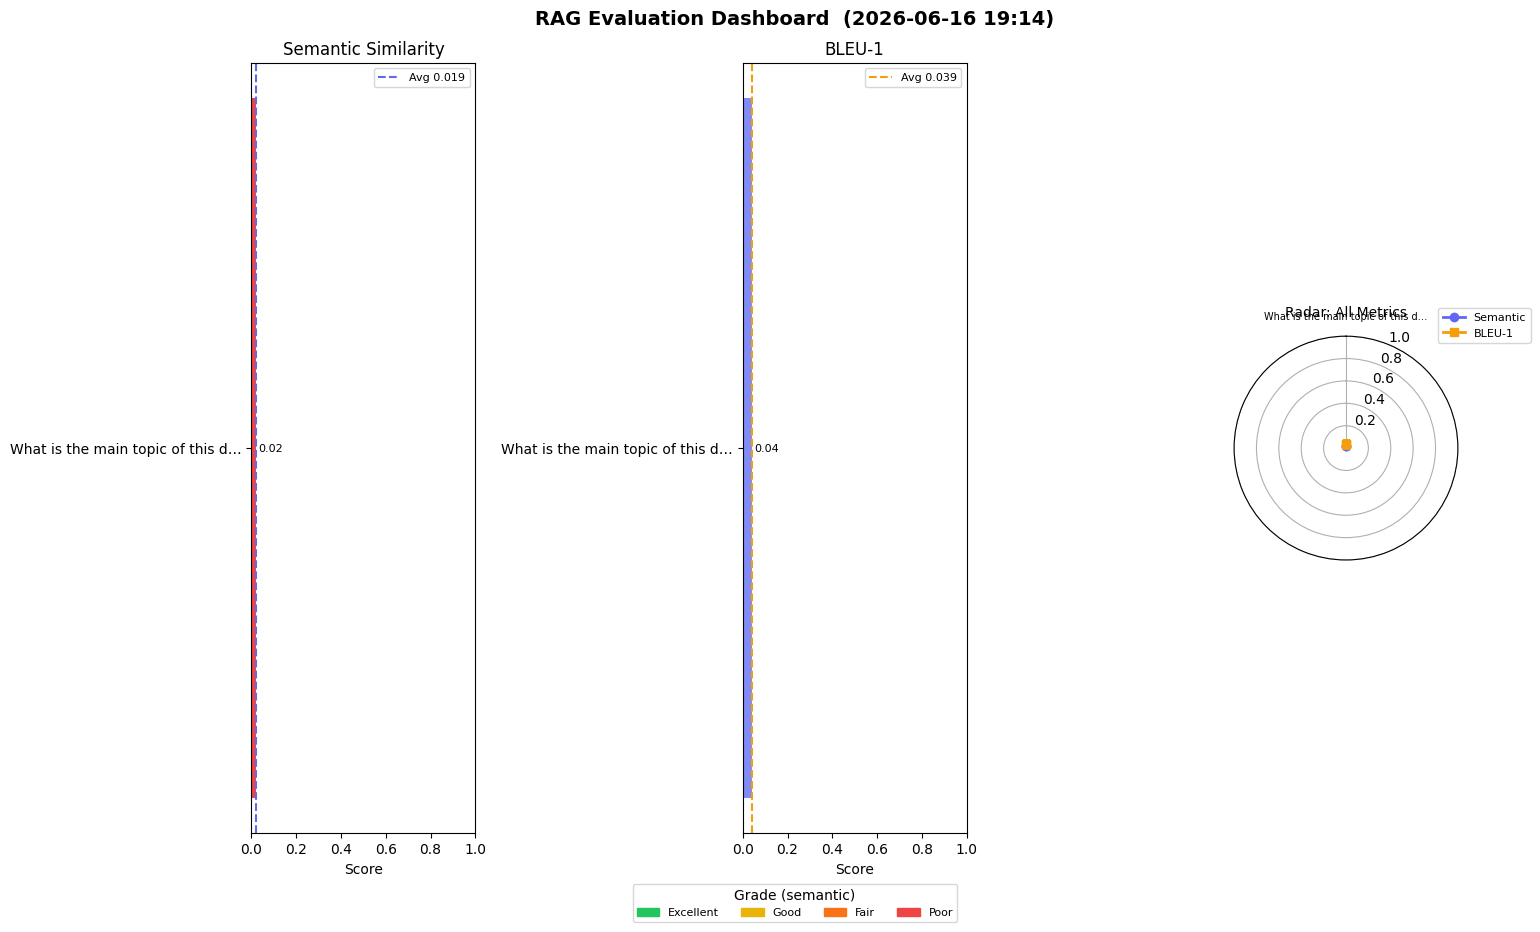

📊 Chart saved to /content/eval_chart.png

📜 Eval history (1 run(s)):
  2026-06-16 19:14  sem=0.019  bleu=0.039  Poor
📄 HTML report saved to /content/eval_report.html


💾 CSV saved to /content/eval_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Cell 10: Evaluation — Auto-Generated Questions + Radar Chart + Run History
import json as _json
import numpy as np
import csv
import datetime
import math
import pathlib
import nltk
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ═══════════════════════════════════════════════════════════════
# STEP 1 — Auto-generate eval Q&A from your actual document
# ═══════════════════════════════════════════════════════════════
NUM_EVAL_QUESTIONS = 4


def _auto_generate_eval_set(n: int = NUM_EVAL_QUESTIONS) -> list[dict]:
    """Ask Gemini to produce Q&A pairs grounded in the ingested documents."""
    _require_documents()
    all_docs = collection.get(include=["documents"])["documents"]
    step     = max(1, math.ceil(len(all_docs) / 20))
    sampled  = all_docs[::step][:20]
    context  = "\n\n".join(sampled)

    prompt = (
        f"You are creating an evaluation dataset. "
        f"Read the document content below and generate exactly {n} question-answer pairs.\n"
        "Rules:\n"
        "- Each question must be answerable ONLY from the content below.\n"
        "- Each answer must be a single complete sentence.\n"
        "- Return ONLY a JSON array — no preamble, no markdown fences.\n"
        "-Format: [{\"question\": \"...\", \"expected\": \"...\"}]\n\n"
        f"DOCUMENT CONTENT:\n{context}"
    )

    raw = call_gemini(prompt, stream=False)
    # Strip accidental markdown fences robustly
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[-1]  # drop the opening ```json line
    if raw.endswith("```"):
        raw = raw.rsplit("```", 1)[0]
    raw = raw.strip()

    try:
        pairs = _json.loads(raw)
        if isinstance(pairs, list) and pairs:
            print(f"\u2705 Auto-generated {len(pairs)} eval question(s) from document.")
            return pairs
    except _json.JSONDecodeError as e:
        print(f"\u26a0\ufe0f  JSON parse failed ({e}) — falling back to manual eval set.")
    return []


# ── Fallback manual eval set (used only if auto-gen fails) ───────
FALLBACK_EVAL_SET: list[dict] = [
    {
        "question": "What is the main topic of this document?",
        "expected":  "The document covers the main topic described in its introduction.",
    },
]

print("\U0001f504 Generating eval questions from your document...")
eval_set = _auto_generate_eval_set(NUM_EVAL_QUESTIONS) or FALLBACK_EVAL_SET
print("\n\U0001f4cb Eval questions:")
for i, item in enumerate(eval_set):
    print(f"  Q{i+1}: {item['question']}")

# ═══════════════════════════════════════════════════════════════
# STEP 2 — Scoring helpers
# ═══════════════════════════════════════════════════════════════
def semantic_similarity(a: str, b: str) -> float:
    """Cosine similarity between two sentences using the shared embedder."""
    vecs = embedder.encode([a, b])
    return float(
        np.dot(vecs[0], vecs[1])
        / (np.linalg.norm(vecs[0]) * np.linalg.norm(vecs[1]))
    )


def bleu1(reference: str, hypothesis: str) -> float:
    """Unigram BLEU score with add-1 smoothing."""
    ref = nltk.word_tokenize(reference.lower())
    hyp = nltk.word_tokenize(hypothesis.lower())
    return sentence_bleu(
        [ref], hyp,
        weights=(1, 0, 0, 0),
        smoothing_function=SmoothingFunction().method1,
    )


def score_label(s: float) -> str:
    """Map a numeric score to a human-readable grade."""
    if s >= 0.90: return "Excellent"
    if s >= 0.80: return "Good"
    if s >= 0.70: return "Fair"
    return "Poor"


GRADE_COLOR: dict[str, str] = {
    "Excellent": "#22c55e",
    "Good":      "#eab308",
    "Fair":      "#f97316",
    "Poor":      "#ef4444",
}

# ═══════════════════════════════════════════════════════════════
# STEP 3 — Run evaluation
# ═══════════════════════════════════════════════════════════════
rows: list[dict] = []
print("\nRunning evaluation...")
for item in eval_set:
    predicted = ask(item["question"], show_sources=False, stream=False)
    sem  = semantic_similarity(predicted, item["expected"])
    bleu = bleu1(item["expected"], predicted)
    rows.append({
        "question":  item["question"],
        "expected":  item["expected"],
        "predicted": predicted,
        "semantic":  round(sem,  4),
        "bleu1":     round(bleu, 4),
        "label":     score_label(sem),
    })
    print(f"  \u2713 {item['question'][:60]}  → sem={sem:.3f}  bleu={bleu:.3f}")

avg_sem  = float(np.mean([r['semantic'] for r in rows]))
avg_bleu = float(np.mean([r['bleu1']    for r in rows]))
run_ts   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

# ═══════════════════════════════════════════════════════════════
# STEP 4 — Charts: bar charts + radar chart
# ═══════════════════════════════════════════════════════════════
questions_short = [
    r['question'][:32] + '\u2026' if len(r['question']) > 32 else r['question']
    for r in rows
]
sem_vals  = [r['semantic'] for r in rows]
bleu_vals = [r['bleu1']    for r in rows]
colors    = [GRADE_COLOR[r['label']] for r in rows]

fig = plt.figure(figsize=(16, 9))
fig.suptitle(f"RAG Evaluation Dashboard  ({run_ts})", fontsize=14, fontweight='bold')

# ── Bar chart: Semantic ───────────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
bars = ax1.barh(questions_short, sem_vals, color=colors)
ax1.set_xlim(0, 1)
ax1.axvline(avg_sem, color='#6366f1', linestyle='--', linewidth=1.5,
            label=f'Avg {avg_sem:.3f}')
ax1.set_xlabel('Score')
ax1.set_title('Semantic Similarity')
ax1.legend(fontsize=8)
for bar, val in zip(bars, sem_vals):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=8)

# ── Bar chart: BLEU-1 ─────────────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
bars2 = ax2.barh(questions_short, bleu_vals, color='#818cf8')
ax2.set_xlim(0, 1)
ax2.axvline(avg_bleu, color='#f59e0b', linestyle='--', linewidth=1.5,
            label=f'Avg {avg_bleu:.3f}')
ax2.set_xlabel('Score')
ax2.set_title('BLEU-1')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, bleu_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=8)

# ── Radar chart ───────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3, polar=True)
N      = len(questions_short)
angles = [n / float(N) * 2 * math.pi for n in range(N)] + [0]  # close loop
sem_radar  = sem_vals  + sem_vals[:1]
bleu_radar = bleu_vals + bleu_vals[:1]

ax3.set_theta_offset(math.pi / 2)
ax3.set_theta_direction(-1)
ax3.set_thetagrids(
    [a * 180 / math.pi for a in angles[:-1]],
    questions_short, fontsize=7, wrap=True,
)
ax3.plot(angles, sem_radar,  'o-', linewidth=2, color='#6366f1', label='Semantic')
ax3.fill(angles, sem_radar,  alpha=0.15, color='#6366f1')
ax3.plot(angles, bleu_radar, 's-', linewidth=2, color='#f59e0b', label='BLEU-1')
ax3.fill(angles, bleu_radar, alpha=0.15, color='#f59e0b')
ax3.set_ylim(0, 1)
ax3.set_title('Radar: All Metrics', fontsize=10, pad=14)
ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=lbl) for lbl, c in GRADE_COLOR.items()]
fig.legend(
    handles=legend_patches, loc='lower center', ncol=4,
    title='Grade (semantic)', bbox_to_anchor=(0.5, -0.04), fontsize=8,
)

plt.tight_layout()
chart_path = '/content/eval_chart.png'
plt.savefig(chart_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'\U0001f4ca Chart saved to {chart_path}')

# ═══════════════════════════════════════════════════════════════
# STEP 5 — Eval history (persist across runs in /content)
# ═══════════════════════════════════════════════════════════════
history_path = pathlib.Path('/content/eval_history.json')
eval_history: list[dict] = (
    _json.loads(history_path.read_text()) if history_path.exists() else []
)

eval_history.append({
    "run":         run_ts,
    "avg_sem":     round(avg_sem,  4),
    "avg_bleu":    round(avg_bleu, 4),
    "grade":       score_label(avg_sem),
    "n_questions": len(rows),
})
history_path.write_text(_json.dumps(eval_history, indent=2))
print(f"\n\U0001f4dc Eval history ({len(eval_history)} run(s)):")
for h in eval_history:
    print(f"  {h['run']}  sem={h['avg_sem']:.3f}  bleu={h['avg_bleu']:.3f}  {h['grade']}")

# ═══════════════════════════════════════════════════════════════
# STEP 6 — HTML report
# ═══════════════════════════════════════════════════════════════
import base64
chart_b64 = base64.b64encode(pathlib.Path(chart_path).read_bytes()).decode()


def _grade_badge(label: str) -> str:
    c = GRADE_COLOR[label]
    return (
        f'<span style="background:{c};color:#fff;padding:2px 8px;'
        f'border-radius:4px;font-size:0.8em;font-weight:bold;">{label}</span>'
    )


rows_html = ""
for i, r in enumerate(rows):
    rows_html += f"""
    <details style='margin:10px 0;border:1px solid #e2e8f0;border-radius:8px;'>
      <summary style='padding:12px 16px;cursor:pointer;background:#f8fafc;
                      border-radius:8px;font-weight:600;'>
        Q{i+1}: {r['question']}
        &nbsp;&nbsp;Semantic: <b>{r['semantic']}</b> {_grade_badge(r['label'])}
        &nbsp;&nbsp;BLEU-1: <b>{r['bleu1']}</b>
      </summary>
      <div style='padding:14px 18px;'>
        <p><b>Expected:</b> {r['expected']}</p>
        <p><b>Got:</b> {r['predicted']}</p>
      </div>
    </details>"""

history_rows = "".join(
    f"<tr><td>{h['run']}</td><td>{h['avg_sem']:.3f}</td>"
    f"<td>{h['avg_bleu']:.3f}</td><td>{h['n_questions']}</td>"
    f"<td>{_grade_badge(h['grade'])}</td></tr>"
    for h in eval_history
)

html_report = f"""
<!DOCTYPE html><html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>RAG Eval Report — {run_ts}</title>
  <style>
    body{{font-family:system-ui,sans-serif;max-width:980px;margin:40px auto;padding:0 20px;color:#1e293b;}}
    h1{{font-size:1.6em;border-bottom:3px solid #6366f1;padding-bottom:8px;}}
    h2{{margin-top:2em;color:#334155;}}
    .grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin:24px 0;}}
    .card{{background:#f8fafc;border:1px solid #e2e8f0;border-radius:10px;padding:18px;text-align:center;}}
    .card .value{{font-size:2em;font-weight:800;color:#6366f1;}}
    .card .metric{{font-size:0.85em;color:#64748b;margin-top:4px;}}
    table{{width:100%;border-collapse:collapse;margin-top:12px;}}
    th,td{{padding:10px 12px;text-align:left;border-bottom:1px solid #e2e8f0;}}
    th{{background:#f1f5f9;font-weight:600;}}
  </style>
</head>
<body>
  <h1>\U0001f4ca RAG Evaluation Report</h1>
  <p style='color:#64748b'>Generated: {run_ts} &nbsp;|&nbsp; {len(rows)} questions</p>
  <div class='grid'>
    <div class='card'><div class='value'>{avg_sem:.3f}</div><div class='metric'>Avg Semantic</div></div>
    <div class='card'><div class='value'>{avg_bleu:.3f}</div><div class='metric'>Avg BLEU-1</div></div>
    <div class='card'><div class='value'>{len(rows)}</div><div class='metric'>Questions</div></div>
    <div class='card'><div class='value' style='font-size:1.4em'>{score_label(avg_sem)}</div><div class='metric'>Grade</div></div>
  </div>
  <h2>Charts</h2>
  <img src='data:image/png;base64,{chart_b64}' style='width:100%;border-radius:8px;'>
  <h2>Per-Question Results</h2>
  {rows_html}
  <h2>\U0001f4dc Eval Run History</h2>
  <table>
    <tr><th>Run</th><th>Avg Semantic</th><th>Avg BLEU-1</th><th>Questions</th><th>Grade</th></tr>
    {history_rows}
  </table>
</body></html>"""

html_path = '/content/eval_report.html'
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_report)
print(f'\U0001f4c4 HTML report saved to {html_path}')

# Inline summary cards
display(HTML(f"""
<div style='display:flex;gap:16px;margin:16px 0;flex-wrap:wrap;'>
  <div style='background:#f0f9ff;border:1px solid #bae6fd;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#0ea5e9'>{avg_sem:.3f}</div>
    <div style='color:#64748b;font-size:0.85em'>Avg Semantic</div></div>
  <div style='background:#faf5ff;border:1px solid #e9d5ff;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#a855f7'>{avg_bleu:.3f}</div>
    <div style='color:#64748b;font-size:0.85em'>Avg BLEU-1</div></div>
  <div style='background:#f0fdf4;border:1px solid #bbf7d0;border-radius:8px;padding:16px 24px;text-align:center'>
    <div style='font-size:1.8em;font-weight:800;color:#22c55e'>{score_label(avg_sem)}</div>
    <div style='color:#64748b;font-size:0.85em'>Grade</div></div>
</div>"""))

# CSV export + auto-download
csv_path = '/content/eval_results.csv'
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(
        f, fieldnames=['question', 'expected', 'predicted', 'semantic', 'bleu1', 'label']
    )
    writer.writeheader()
    writer.writerows(rows)
print(f'\U0001f4be CSV saved to {csv_path}')

try:
    from google.colab import files as _cf
    for p in [csv_path, html_path, chart_path]:
        _cf.download(p)
except Exception:
    pass